## **Task 1**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and dates
temperatures = df["value"]

dates = pd.to_datetime(df["referenceTime"])

# Plot the data
plt.plot(dates, temperatures)

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

# Calculate statistics
mean_temp = temperatures.mean()
median_temp = temperatures.median()
min_temp = temperatures.min()
max_temp = temperatures.max()

# Print the statistics in a formatted table
print(f"{'Statistic':<20} {'Temperature (°C)':>16}")
print("-" * 37)
print(f"{'Mean':<20} {mean_temp:>16.2f}")
print(f"{'Median':<20} {median_temp:>16.2f}")
print(f"{'Minimum':<20} {min_temp:>16.2f}")
print(f"{'Maximum':<20} {max_temp:>16.2f}")


## **Task 2**

Data retrieved from frost.met.no!


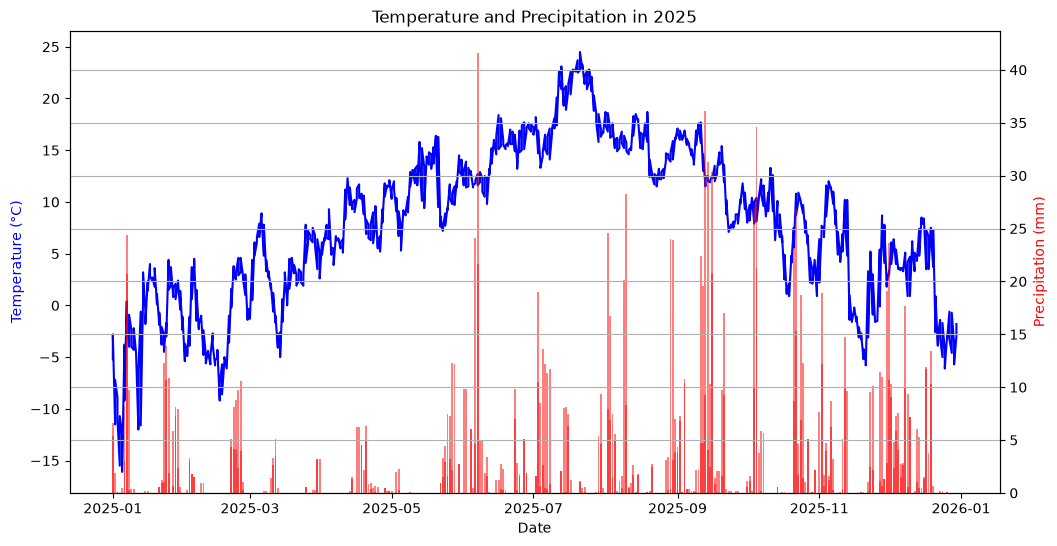

In [70]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D),sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and precipitation data
temperatures = df[df["elementId"] == "mean(air_temperature P1D)"]["value"]
temperature_dates = pd.to_datetime(df[df["elementId"] == "mean(air_temperature P1D)"]["referenceTime"])

precipitations = df[df["elementId"] == "sum(precipitation_amount P1D)"]["value"]
precipitation_dates = pd.to_datetime(df[df["elementId"] == "sum(precipitation_amount P1D)"]["referenceTime"])

# Plot the data with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature on the left y-axis
ax1.plot(
    temperature_dates,
    temperatures,
    color="blue",
    label="Temperature"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)", color="blue")

# Create a new y-axis
ax2 = ax1.twinx()

# Precipitation on the right y-axis
ax2.bar(
    precipitation_dates,
    precipitations,
    color="red",
    alpha=0.5,
    label="Precipitation"
)
ax2.set_ylabel("Precipitation (mm)", color="red")

plt.title("Temperature and Precipitation in 2025")
plt.grid(True)
plt.show()


## **Task 3**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters_2025 = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

parameters_1925 = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "1925-01-01/1925-12-31",
}

# Issue an HTTP GET request
r_2025 = requests.get(endpoint, params=parameters_2025, auth=(client_id, ""))
r_1925 = requests.get(endpoint, params=parameters_1925, auth=(client_id, ""))

# Extract JSON data
json_2025 = r_2025.json()
json_1925 = r_1925.json()

# Check if the request worked, print out any errors
if r_2025.status_code == 200:
    data_2025 = json_2025["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r_2025.status_code)
    print("Message: %s" % json_2025["error"]["message"])
    print("Reason: %s" % json_2025["error"]["reason"])

# For the 1925 data
if r_1925.status_code == 200:
    data_1925 = json_1925["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r_1925.status_code)
    print("Message: %s" % json_1925["error"]["message"])
    print("Reason: %s" % json_1925["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df_2025 = pd.DataFrame()
df_1925 = pd.DataFrame()
rows_2025 = []
rows_1925 = []
for i in range(len(data_2025)):
    row = pd.DataFrame(data_2025[i]["observations"])
    row["referenceTime"] = data_2025[i]["referenceTime"]
    row["sourceId"] = data_2025[i]["sourceId"]
    rows_2025.append(row)

for i in range(len(data_1925)):
    row = pd.DataFrame(data_1925[i]["observations"])
    row["referenceTime"] = data_1925[i]["referenceTime"]
    row["sourceId"] = data_1925[i]["sourceId"]
    rows_1925.append(row)

df_2025 = pd.concat(rows_2025, ignore_index=True)
df_1925 = pd.concat(rows_1925, ignore_index=True)

# Extract temperatures and dates
temperatures_2025 = df_2025["value"]
temperatures_1925 = df_1925["value"]

dates_2025 = pd.to_datetime(df_2025["referenceTime"])
dates_1925 = pd.to_datetime(df_1925["referenceTime"])

days_2025 = dates_2025.dt.dayofyear
days_1925 = dates_1925.dt.dayofyear

# Plot the data
plt.plot(days_2025, temperatures_2025, label="2025", color='blue')
plt.plot(days_1925, temperatures_1925, label="1925", color='red')

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025 vs 1925")
plt.xlabel("Day of Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()

plt.show()

# Calculate statistics
mean_temp_2025 = temperatures_2025.mean()
median_temp_2025 = temperatures_2025.median()
min_temp_2025 = temperatures_2025.min()
max_temp_2025 = temperatures_2025.max()

mean_temp_1925 = temperatures_1925.mean()
median_temp_1925 = temperatures_1925.median()
min_temp_1925 = temperatures_1925.min()
max_temp_1925 = temperatures_1925.max()

# Print the statistics in a formatted table
print(f"{'Statistic':<20} {'Temperature (°C)':>31}")
print("-" * 55)
print(f"{'Year':<20} {'2025':>16} {'1925':>16}")
print("-" * 55)
print(f"{'Mean':<20} {mean_temp_2025:>16.2f} {mean_temp_1925:>16.2f}")
print(f"{'Median':<20} {median_temp_2025:>16.2f} {median_temp_1925:>16.2f}")
print(f"{'Minimum':<20} {min_temp_2025:>16.2f} {min_temp_1925:>16.2f}")
print(f"{'Maximum':<20} {max_temp_2025:>16.2f} {max_temp_1925:>16.2f}")

## **Task 4**

In [77]:
import requests
import pandas as pd
import yaml

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()


def heatwave_summary_to_yml(station_id, station_name, year):
    """
    Retrieve heatwave data for a given station and year, and save it to a YAML file.
    """
    # Define endpoint and parameters
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
    "sources": f"{station_id}",
    "elements": "max(air_temperature P1D)",
    "referencetime": f"{year}-01-01/{year}-12-31",
    }

    # Issue an HTTP GET request
    r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

    # Extract JSON data
    json = r.json()

    # Check if the request worked, print out any errors
    if r.status_code == 200:
        data = json["data"]
        print("Data retrieved from frost.met.no!")
    else:
        print("Error! Returned status code %s" % r.status_code)
        print("Message: %s" % json["error"]["message"])
        print("Reason: %s" % json["error"]["reason"])

    # This will return a Dataframe with all of the observations in a table format
    df = pd.DataFrame()
    rows = []
    for i in range(len(data)):
        row = pd.DataFrame(data[i]["observations"])
        row["referenceTime"] = data[i]["referenceTime"]
        row["sourceId"] = data[i]["sourceId"]
        rows.append(row)

    # Concatenate all rows into a single DataFrame
    df = pd.concat(rows, ignore_index=True)

    # Convert the referenceTime column to datetime format
    df["referenceTime"] = pd.to_datetime(df["referenceTime"]) 

    # Calculate daily maximum temperatures (2 observations per day, so we take the max)
    daily_temperatures = df.groupby(df["referenceTime"].dt.date)["value"].max()

    # Prepare the heatwave summary data structure
    heatwave_data = {
            "dates" : [],
            "station_id": station_id,
            "station_name": station_name,
            "year": year,
        }

    # Count consecutive days with temperatures >= 27°C, and store the start and end dates of heatwaves
    number_of_days = 0
    start_date = None

    for date, temp in daily_temperatures.items():

        if temp >= 27:
            number_of_days += 1

            if number_of_days == 1:
                start_date = date

        else:
            if number_of_days >= 5:
                end_date = date - pd.Timedelta(days=1)

                heatwave_data["dates"].append(f"{start_date.strftime('%Y-%m-%d')} - {end_date.strftime('%Y-%m-%d')}")

            number_of_days = 0
            start_date = None

    # Save the heatwave summary to a YAML file
    with open(f"heatwave_summary_{station_id}_{year}.yml", "w") as file:
        yaml.dump(heatwave_data, file)

    print(f"Heatwave summary saved to heatwave_summary_{station_id}_{year}.yml")

heatwave_summary_to_yml("SN17850", r"\xC5s", 2025)
            

Data retrieved from frost.met.no!
Heatwave summary saved to heatwave_summary_SN17850_2025.yml
